# Multiple-Participant Behavioural Simulation

## Aim

This notebook simulates reaction-time and accuracy data from 30 participants performing congruent and incongruent trials.

Participants differ in their baseline reaction time and the size of their interference effect. All data are synthetic.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

rng = np.random.default_rng(seed=123)

n_participants = 30
trials_per_participant = 100

participant_datasets = []

for participant_number in range(1, n_participants + 1):

    participant_id= f"sub-{participant_number:03d}"

    baseline_rt = rng.normal(loc=500, scale=40)
    interference_rt = rng.normal(loc=100, scale=20)

    congruent_accuracy = np.clip(rng.normal(loc=0.95, scale=0.02), 0.80, 0.99,)  

    incongruent_accuracy = np.clip(rng.normal(loc=0.85, scale=0.04), 0.60, 0.98,)

    conditions = np.repeat(["congruent", "incongruent"],trials_per_participant // 2)

    rng.shuffle(conditions)

    expected_rt =  np.where(conditions == "congruent", baseline_rt, baseline_rt + interference_rt)

    reaction_times = rng.normal(loc=expected_rt, scale=65).round(1)

    accuracy_probability = np.where(conditions == "congruent", congruent_accuracy, incongruent_accuracy)

    correct_responses = rng.binomial(1, p=accuracy_probability)

    participant_data = pd.DataFrame({"participant": participant_id, "trial": np.arange(1, trials_per_participant + 1), "condition": conditions, "rt_ms": reaction_times, "correct": correct_responses,})

    participant_datasets.append(participant_data)

    data_multi = pd.concat(participant_datasets, ignore_index=True)

    data_multi.head(10)





In [9]:
print(data_multi.shape)
print(data_multi["participant"].nunique())
print(data_multi["condition"].value_counts())

(3000, 5)
30
condition
congruent      1500
incongruent    1500
Name: count, dtype: int64


In [10]:
participant_summary = data_multi.groupby(["participant", "condition"], as_index=False,).agg(mean_rt_ms=("rt_ms", "mean"), mean_accuracy=("correct", "mean"), n_trials=("trial", "count"),)

participant_summary.head(6)



,participant,condition,mean_rt_ms,mean_accuracy,n_trials
0,sub-001,congruent,459.766,0.96,50
1,sub-001,incongruent,569.516,0.78,50
2,sub-002,congruent,510.312,0.90,50
3,sub-002,incongruent,592.670,0.78,50
4,sub-003,congruent,515.150,0.98,50
5,sub-003,incongruent,606.016,0.92,50


In [11]:
rt_wide=participant_summary.pivot(index="participant", columns="condition", values="mean_rt_ms")

rt_wide["interference_effect"] = rt_wide["incongruent"] - rt_wide["congruent"]

rt_wide.head()

condition,congruent,incongruent,interference_effect
participant,,,
sub-001,459.766,569.516,109.750
sub-002,510.312,592.670,82.358
sub-003,515.150,606.016,90.866
sub-004,538.344,665.944,127.600
sub-005,559.862,671.088,111.226


In [12]:
mean_interference_effect = rt_wide["interference_effect"].mean()
sd_interference_effect = rt_wide["interference_effect"].std()

print(f"Mean interference effect: {mean_interference_effect:.2f} ms")
print(f"Standard deviation of interference effect: {sd_interference_effect:.2f} ms")

Mean interference effect: 97.20 ms
Standard deviation of interference effect: 27.79 ms


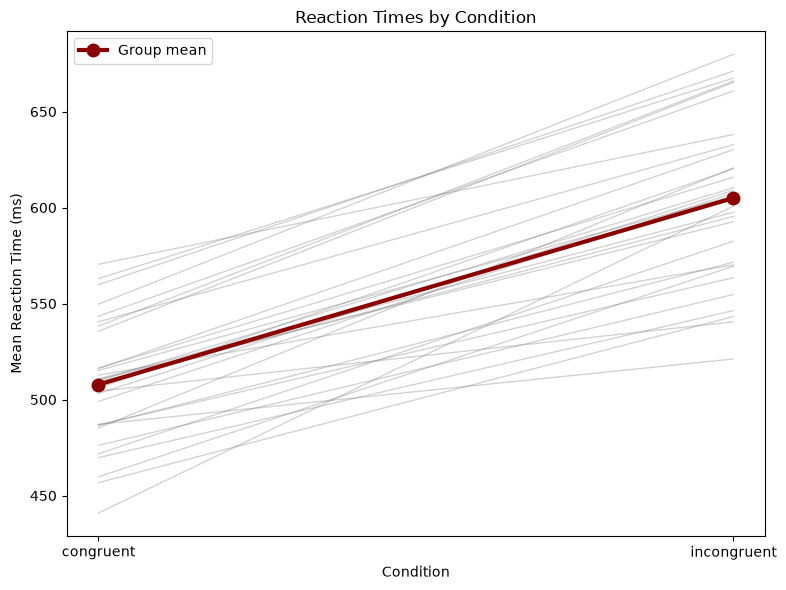

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

for participant, values in rt_wide.iterrows():
    ax.plot(["congruent", "incongruent"], [values["congruent"], values["incongruent"]], color="gray", alpha=0.35, linewidth=1)

group_means = rt_wide[["congruent", "incongruent"]].mean()

ax.plot(
    ["congruent", "incongruent"],
    [group_means["congruent"], group_means["incongruent"]],
    color="darkred",
    marker="o",
    markersize=9,
    linewidth=3,
    label="Group mean",)

ax.set_title("Reaction Times by Condition")
ax.set_xlabel("Condition")
ax.set_ylabel("Mean Reaction Time (ms)")
ax.legend()
plt.tight_layout()

fig.savefig("paired_reaction_times.png", dpi=300, bbox_inches="tight")

plt.show()



NameError: name 'figures_folder' is not defined

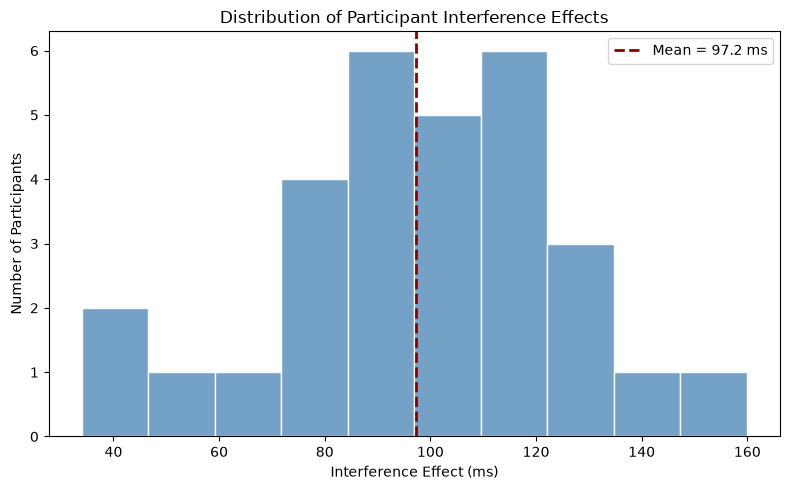

In [14]:
rt_wide["interference_ms"] = (
    rt_wide["incongruent"]
    - rt_wide["congruent"]
)

mean_effect = rt_wide["interference_ms"].mean()

fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(
    data=rt_wide,
    x="interference_ms",
    bins=10,
    color="steelblue",
    edgecolor="white",
    ax=ax,
)

ax.axvline(
    mean_effect,
    color="darkred",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_effect:.1f} ms",
)

ax.set_title("Distribution of Participant Interference Effects")
ax.set_xlabel("Interference Effect (ms)")
ax.set_ylabel("Number of Participants")
ax.legend()

plt.tight_layout()

fig.savefig(
    figures_folder / "interference_effect_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [ ]:
from scipy import stats

t_test = stats.ttest_rel(rt_wide["congruent"], rt_wide["incongruent"])

cohens_dz = rt_wide["interference_effect"].mean() / rt_wide["interference_effect"].std()

print(f"t-statistic: {t_test.statistic:.2f}")
print(f"p-value: {t_test.pvalue:.4f}")
print(f"Cohen's dz: {cohens_dz:.2f}")

t-statistic: -19.16
p-value: 0.0000
Cohen's dz: 3.50


In [ ]:
mean_effect = rt_wide["interference_effect"].mean()
standard_error = stats.sem(rt_wide["interference_effect"])

confidence_interval = stats.t.interval(0.95, df=len(rt_wide) - 1, loc=mean_effect, scale=standard_error)

print(f"Mean interference effect: {mean_effect:.2f} ms")
print(
    f"95% CI: [{confidence_interval[0]:.2f}, "
    f"{confidence_interval[1]:.2f}] ms")



Mean interference effect: 97.20 ms
95% CI: [86.82, 107.57] ms


In [ ]:
from pathlib import Path

data_folder = Path("../data")
figures_folder = Path("../figures")

data_folder.mkdir( exist_ok=True)
figures_folder.mkdir( exist_ok=True)

data_multi.to_csv(data_folder / "simulated_multiple_participants.csv", index=False)

participant_summary.to_csv(data_folder / "participant_condition_summary.csv", index=False)

rt_wide.to_csv(data_folder / "participant_interference_effects.csv", index=True)

print("Data and summaries saved.")

Data and summaries saved.


## Results

Across 30 simulated participants, mean reaction time was 97.20 ms slower
during incongruent trials than during congruent trials, 95% CI
[86.82, 107.57] ms.

The paired plot shows the within-participant change between conditions.
The histogram shows how interference effects varied across participants.

## Interpretation

The results illustrate cognitive interference: competing information increased
the time required to respond.

All observations are synthetic. 

